# Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Master Dataset

Load the master dataset generated during the preprocessing stage. This dataset contains the merged sustainability reports, ESG information, and generated claim features.

In [ ]:
merged = pd.read_csv("Master_Dataset.csv")

# Remove unnecessary index column if it exists
if "Unnamed: 0" in merged.columns:
    merged = merged.drop(columns=["Unnamed: 0"])

print(merged.head())

           filename ticker  year  \
0  ASX_BSX_2020.pdf    BSX  2020   
1  ASX_BSX_2022.pdf    BSX  2022   
2  ASX_EXR_2022.pdf    EXR  2022   
3  LSE_ADM_2019.pdf    ADM  2019   
4  LSE_ADM_2020.pdf    ADM  2020   

                                preprocessed_content  \
0  style guide colour colour use imagecolour prof...   
1  sustainability report look mining green office...   
2  report environment social governance esg basel...   
3  corporate social responsibilty report introduc...   
4  sustainability admiral commit maintain respons...   

                                        ner_entities  e_score  s_score  \
0  ['bk%', 'rgb', 'un', 'el ectric mine consortiu...     3.16    18.00   
1  ['murray street', 'west perth', 'west perth', ...     2.83    12.86   
2  ['september', 'mongolia', 'australia', 'austra...     3.81     4.28   
3  ['david stevens', 'csr board', 'just over  yea...    16.38    14.20   
4  ['year', 'health & wellbeing', 'a -month', 'on...    15.89    13.51   

 

# Create Industry-Level Comparison Table

In [ ]:
industry_claims = pd.crosstab(
    merged['Industry'],
    merged['claim_type']
)

industry_claims['Vague_Percentage'] = (
    industry_claims['Vague'] /
    (industry_claims['Vague'] + industry_claims['Concrete'])
) * 100

industry_claims = industry_claims.sort_values(
    by='Vague_Percentage',
    ascending=False
)

print(industry_claims.head(10))

claim_type                           Concrete  Vague  Vague_Percentage
Industry                                                              
Advertising Agencies                        0      3             100.0
Aerospace & Defense                         0      9             100.0
Agricultural Inputs                         0      4             100.0
Auto Manufacturers                          0      3             100.0
Auto & Truck Dealerships                    0      4             100.0
Beverages - Wineries & Distilleries         0      3             100.0
Banks - Regional                            0     23             100.0
Auto Parts                                  0     13             100.0
Banks - Diversified                         0      8             100.0
Copper                                      0      4             100.0


In [ ]:
industry_claims['Total_Reports'] = (
    industry_claims['Concrete'] +
    industry_claims['Vague']
)

filtered_industries = industry_claims[
    industry_claims['Total_Reports'] >= 10
]

filtered_industries = filtered_industries.sort_values(
    by='Vague_Percentage',
    ascending=False
)

print(filtered_industries.head(10))

claim_type                        Concrete  Vague  Vague_Percentage  \
Industry                                                              
Banks - Regional                         0     23        100.000000   
Auto Parts                               0     13        100.000000   
Medical Devices                          0     22        100.000000   
Telecom Services                         0     15        100.000000   
Resorts & Casinos                        0     12        100.000000   
Integrated Freight & Logistics           0     18        100.000000   
Drug Manufacturers - General             1     21         95.454545   
Financial Data & Stock Exchanges         1     16         94.117647   
Specialty Industrial Machinery           2     26         92.857143   
REIT - Specialty                         1     13         92.857143   

claim_type                        Total_Reports  
Industry                                         
Banks - Regional                             23

# Visualize Industry Differences

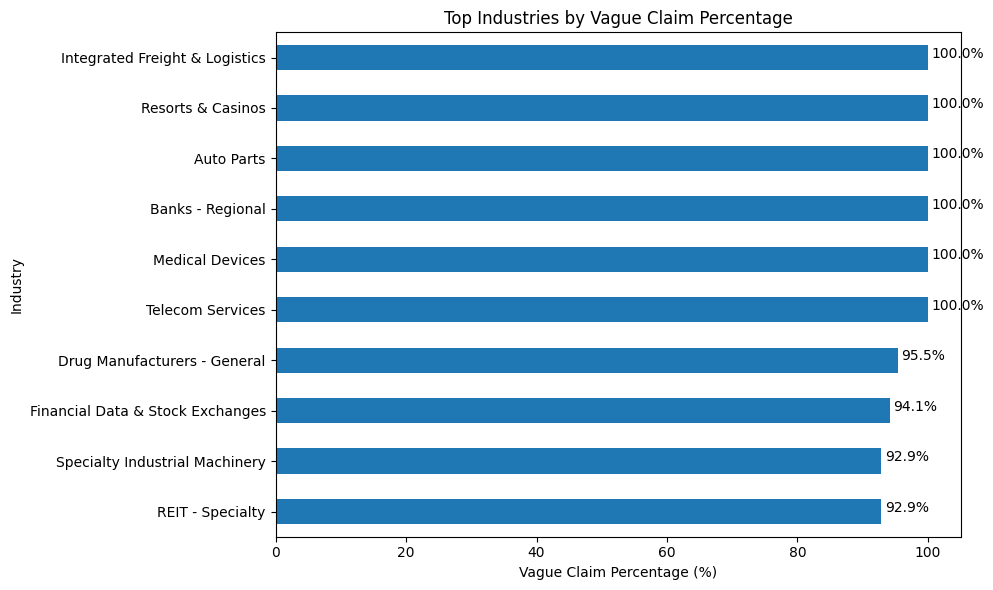

In [ ]:
top10 = filtered_industries.head(10)

plt.figure(figsize=(10, 6))

top10['Vague_Percentage'].sort_values().plot(kind='barh')

plt.title("Top Industries by Vague Claim Percentage")
plt.xlabel("Vague Claim Percentage (%)")
plt.ylabel("Industry")

for i, value in enumerate(top10['Vague_Percentage'].sort_values()):
    plt.text(value + 0.5, i, f"{value:.1f}%")

plt.tight_layout()

# Save figure here, before plt.show()
plt.savefig(
    "RQ3_Top_Industries_by_Vague_Claims.pdf",
    bbox_inches="tight"
)

plt.show()

# Save Figure and Table

In [ ]:
# Save table
top10.to_csv(
    "RQ3_Top_Industries_by_Vague_Claims.csv",
    index=True
)

# Save figure
plt.savefig(
    "RQ3_Top_Industries_by_Vague_Claims.pdf",
    bbox_inches='tight'
)

print("RQ3 outputs saved successfully.")

RQ3 outputs saved successfully.


<Figure size 640x480 with 0 Axes>